In [1]:
import pickle

with open('data/data_figure2', 'rb') as f:
    mydata = pickle.load(f)

list_width_n, list_scaling_m, list_training_steps, test_xs_1d, iterate, kernel_ana_list = mydata

In [2]:
from IPython.display import set_matplotlib_formats
import matplotlib_inline

matplotlib_inline.backend_inline.set_matplotlib_formats('pdf', 'svg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

import numpy as np

from matplotlib import colormaps as cm

# Define plot colors
viridis = cm['viridis']
vir1 = viridis(0.1)
vir2 = viridis(0.6)

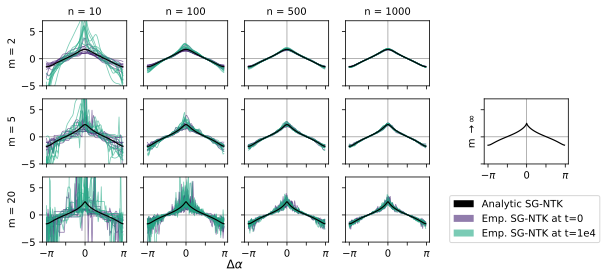

In [3]:
# Set subplot
n_list_training_steps = len(list_training_steps)
n_list_width_n = len(list_width_n)
n_list_scaling_m = len(list_scaling_m)
subplot_width = n_list_width_n
subplot_height = n_list_scaling_m

fig_main, axes_main = plt.subplots(nrows=subplot_height, ncols=subplot_width+1, sharex=True, sharey='row') # "ncols=subplot_width+1" to create an extra column for the case m=infinity
fig_main.set_size_inches(8.75,4)
axes_main[0,0].set_xticks((-np.pi,-np.pi/2,0,np.pi/2,np.pi), ('$-\\pi$','','0','','$\\pi$'))
fig_main.supxlabel('$\\Delta\\alpha$', x=.43)

alpha = .6

# Plot emp. and analytic SG-NTK
for i, n in enumerate(list_width_n):
    for j, m in enumerate(list_scaling_m):
            axes_main[j, i].axvline(0, linestyle='-', color='grey', linewidth=.6)
            axes_main[j, i].axhline(0, linestyle='-', color='grey', linewidth=.6)
            
            axes_main[j, i].plot(test_xs_1d, iterate[j*len(list_width_n)+i][1][0].transpose(), color=vir1, linewidth=0.8, alpha = alpha)
            axes_main[j, i].plot(test_xs_1d, iterate[j*len(list_width_n)+i][1][1].transpose(), color=vir2, linewidth=0.8, alpha = alpha)
            axes_main[j, i].plot(test_xs_1d, kernel_ana_list[j], color='k', linewidth=1.2)    
    
for ax, n in zip(axes_main[0,:], list_width_n):
    ax.set_title("n = "+str(n), size=10)
for ax, m in zip(axes_main[:,0], list_scaling_m):
    ax.set_ylabel("m = "+str(m), size=10)

# Set y_lim
axes_main[0,0].set_ylim(-5,7)
axes_main[1,0].set_ylim(-5,7)
axes_main[2,0].set_ylim(-5,7)

labels_main = ['Analytic SG-NTK', 'Emp. SG-NTK at t='+str(list_training_steps[0]), 'Emp. SG-NTK at t=1e4']

black_patch = mpatches.Patch(facecolor='k')
patch1 = mpatches.Patch(facecolor=vir1, alpha=alpha)
patch2 = mpatches.Patch(facecolor=vir2, alpha=alpha)

fig_main.legend(handles = [black_patch, patch1, patch2], labels=labels_main,
       loc="upper left",
        borderaxespad=0.1, bbox_to_anchor=(.77, 0.275), prop={'size': 10})

# Modify the last column of the plot
fig_main.delaxes(axes_main[0,4])
fig_main.delaxes(axes_main[2,4])

pos = axes_main[1,4].get_position()
new_pos = [pos.x0+.06, pos.y0, pos.width, pos.height]
axes_main[1,4].set_position(new_pos)

axes_main[1,4].set_ylabel("m $\\to \\infty$")

axes_main[1, 4].axvline(0, linestyle='-', color='grey', linewidth=.6)
axes_main[1, 4].axhline(0, linestyle='-', color='grey', linewidth=.6)

# Calculate the analytic SG-NTK for m=infinity
from ntk_definitions import *
from sg_ntk_definitions import *
test_points = 100
train_points = 15
target_fn = lambda x: 4*x[0]*x[1]**2 - 0.8*x[0]**3 + 1.2*x[1]**2 - 0.8*x[0]**2*x[1]

test_xs, test_xs_1d, test_ys, train_xs, train_xs_1d, train_ys = generate_dataset(target_fn, train_points, test_points, 0., random.PRNGKey(2))
shape = (2, 10, 10, 1)
kernel_ana_erf = erf_ntk(test_xs, test_xs, len(shape)-1, -1, 1, 'erf')

# Plot the analytic SG-NTK
axes_main[1,4].plot(test_xs_1d, kernel_ana_erf[int(test_points/2),:], color='k', linewidth=1.2)

axes_main[1,4].tick_params(labelbottom=True)

fig_main.savefig("plots/figure2.pdf", bbox_inches='tight')
plt.show()

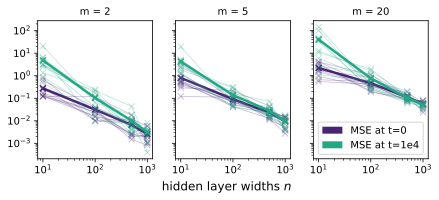

In [ ]:
# Set subplot for error plots

fig_error, axes_error = plt.subplots(nrows=1, ncols=len(list_scaling_m), sharex=True, sharey=True)
fig_error.set_size_inches(7,2.5)

errors = np.zeros((len(list_width_n),len(list_scaling_m),2,10))

# Calculate errors
for i, n in enumerate(list_width_n):
    for j, m in enumerate(list_scaling_m):
            errors[i,j,0,:] = np.mean(np.square(iterate[j*len(list_width_n)+i][1][0].transpose() - np.reshape(kernel_ana_list[j],(100,1))), axis=0)
            errors[i,j,1] = np.mean(np.square(iterate[j*len(list_width_n)+i][1][1].transpose() - np.reshape(kernel_ana_list[j],(100,1))), axis=0)

# Plot errors
for j, m in enumerate(list_scaling_m):
    axes_error[j].plot(list_width_n, errors[:,j,0,:], color=vir1, linestyle='-', marker='x', linewidth=0.8, alpha=.3)
    axes_error[j].plot(list_width_n, np.mean(errors[:,j,0,:],axis=1), color=vir1, linestyle='-', marker='x', linewidth=2.5, mew = 1.5)
    axes_error[j].plot(list_width_n, errors[:,j,1,:], color=vir2, linestyle='-', marker='x', linewidth=0.8, alpha=.3)
    axes_error[j].plot(list_width_n, np.mean(errors[:,j,1,:],axis=1), color=vir2, linestyle='-', marker='x', linewidth=2.5, mew = 1.5)
    axes_error[j].set_title("m = "+str(m), size=10)

# Set axes scaling, labels, and legend patches
plt.yscale('log')
plt.xscale('log')
fig_error.supxlabel('hidden layer widths $n$', x=0.5,y=-0.08)
labels_main = ['MSE at t='+str(list_training_steps[0]), 'MSE at t=1e4']
green_patch = mpatches.Patch(facecolor=vir1, alpha=1)
orange_patch = mpatches.Patch(facecolor=vir2, alpha=1)
fig_error.legend(handles = [green_patch, orange_patch], labels=labels_main,
       loc="upper left",
        borderaxespad=0.1, bbox_to_anchor=(.68, 0.32), prop={'size': 10})
fig_error.savefig("plots/figure_b4.pdf", bbox_inches='tight')
plt.show()